In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, LeaveOneGroupOut, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.multioutput import RegressorChain
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
from matplotlib.font_manager import FontProperties
from matplotlib.font_manager import findfont

#sns.set_palette([  "#89A8F6","#0F42C6",'#C9CED5',  "#1C2029"])

sns.set_style('darkgrid',{
    "axes.facecolor": "#f0f0f0",
    "axes.linewidth": 1.5,
    'axes.grid': True,
    'axes.labelcolor': '#000',
    "font.size": 18,
    'axes.edgecolor': '#fff',
    'grid.color': '#9d9d9d',
    'text.color': '#000',
    'xtick.color': '#000'
})

In [ ]:
df_a = pd.read_csv("bench_results/results_A.csv")
df_b = pd.read_csv("bench_results/results_B.csv")
df_c = pd.read_csv("bench_results/results_C.csv")

df = pd.concat([df_a, df_b, df_c], ignore_index=True)

In [29]:
df['estimated_nodes'] = df['F'] * (df['W']**(df['D'] + 1) - 1) / (df['W'] - 1)

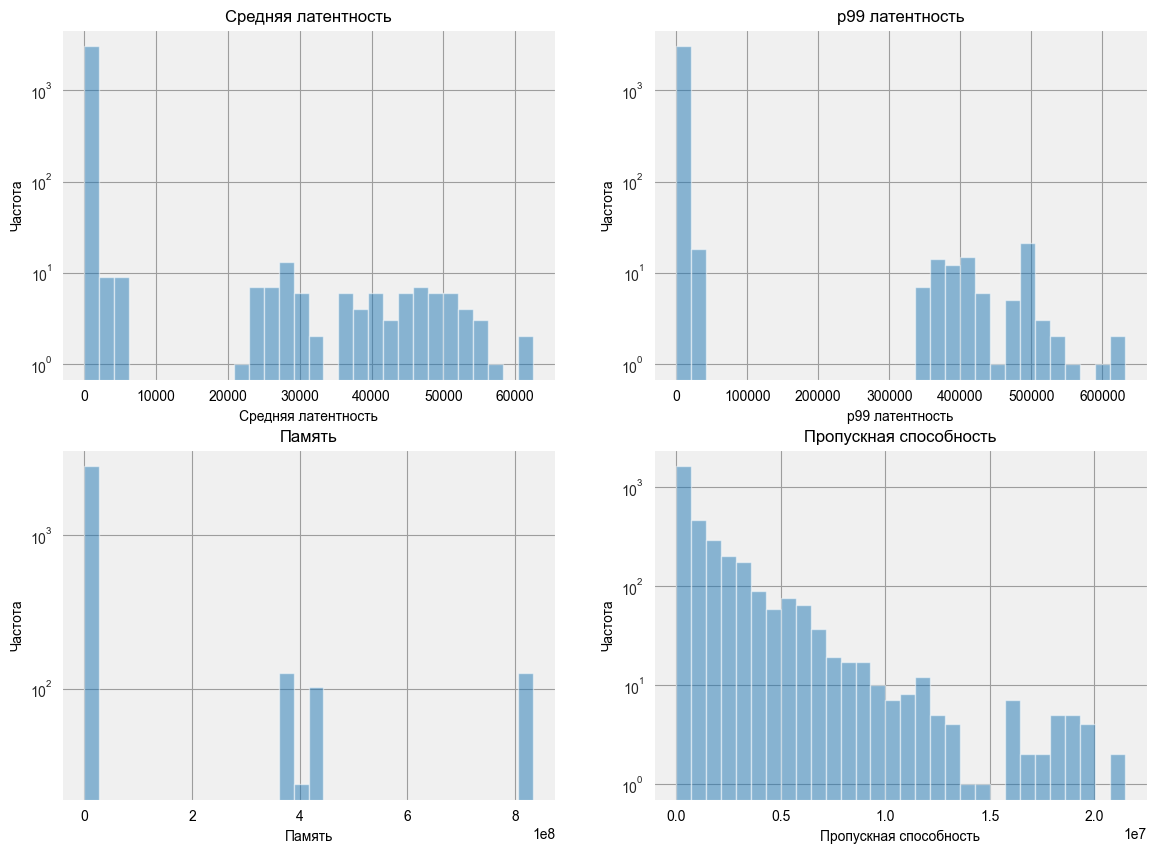

In [63]:
metrics = ['avg_latency_us', 'p99_latency_us', 'memory_usage_bytes', 'throughput_ops_sec']
titles = ['Средняя латентность', 'p99 латентность', 'Память', 'Пропускная способность']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, title in zip(axes.flat, metrics, titles):
    ax.hist(df[metric], bins=30, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Частота')
    ax.set_yscale('log')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


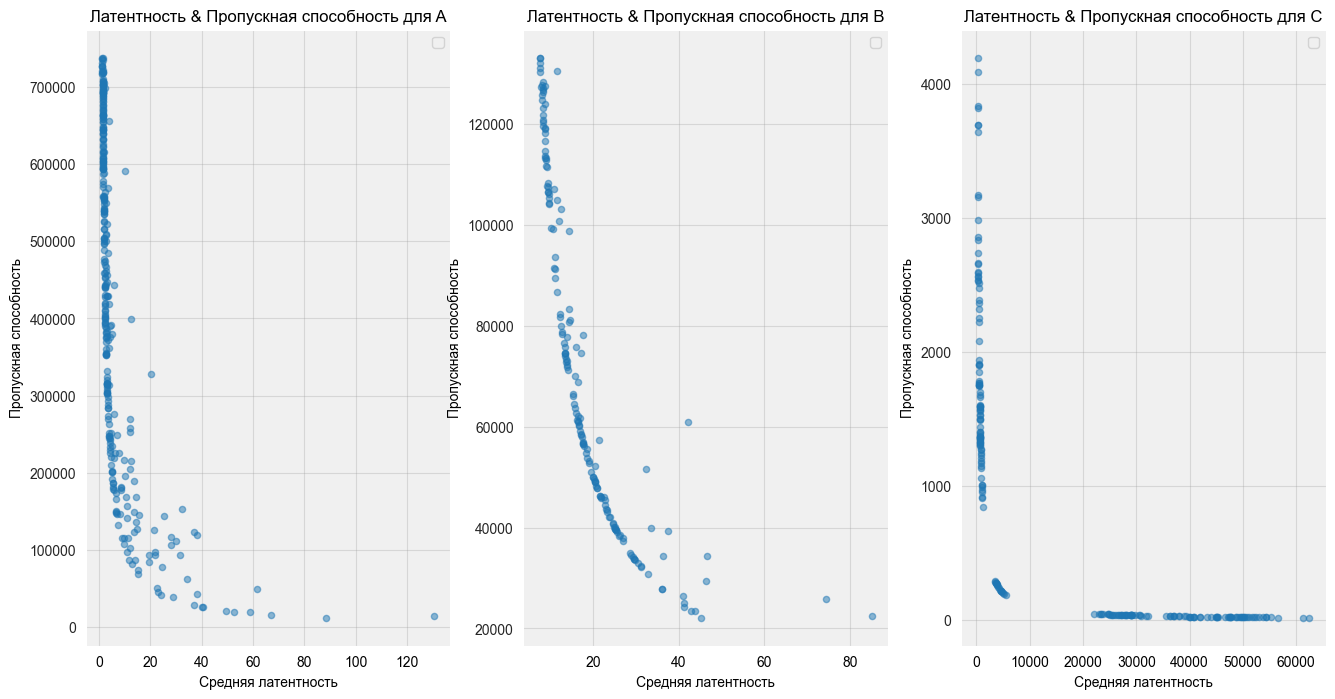

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

approaches = ['A','B','C']

for i in [0, 1, 2]:
    sub = df[df['fs_type']==approaches[i]]
    if (sub["throughput_ops_sec"].max() > 1.5*1e7) :
        sub = sub[sub["throughput_ops_sec"] < sub["throughput_ops_sec"].max()/5000]
    elif(sub["throughput_ops_sec"].max() > 1e7):
        sub = sub[sub["throughput_ops_sec"] < sub["throughput_ops_sec"].max()/100]
    else :
        sub = sub[sub["throughput_ops_sec"] < sub["throughput_ops_sec"].max()/10]
        
    axes[i].scatter(sub['avg_latency_us'], sub['throughput_ops_sec'], alpha=0.5, s=20)
    axes[i].set_xlabel('Средняя латентность')
    axes[i].set_ylabel('Пропускная способность')
    axes[i].set_title(f'Латентность & Пропускная способность для {approaches[i]}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

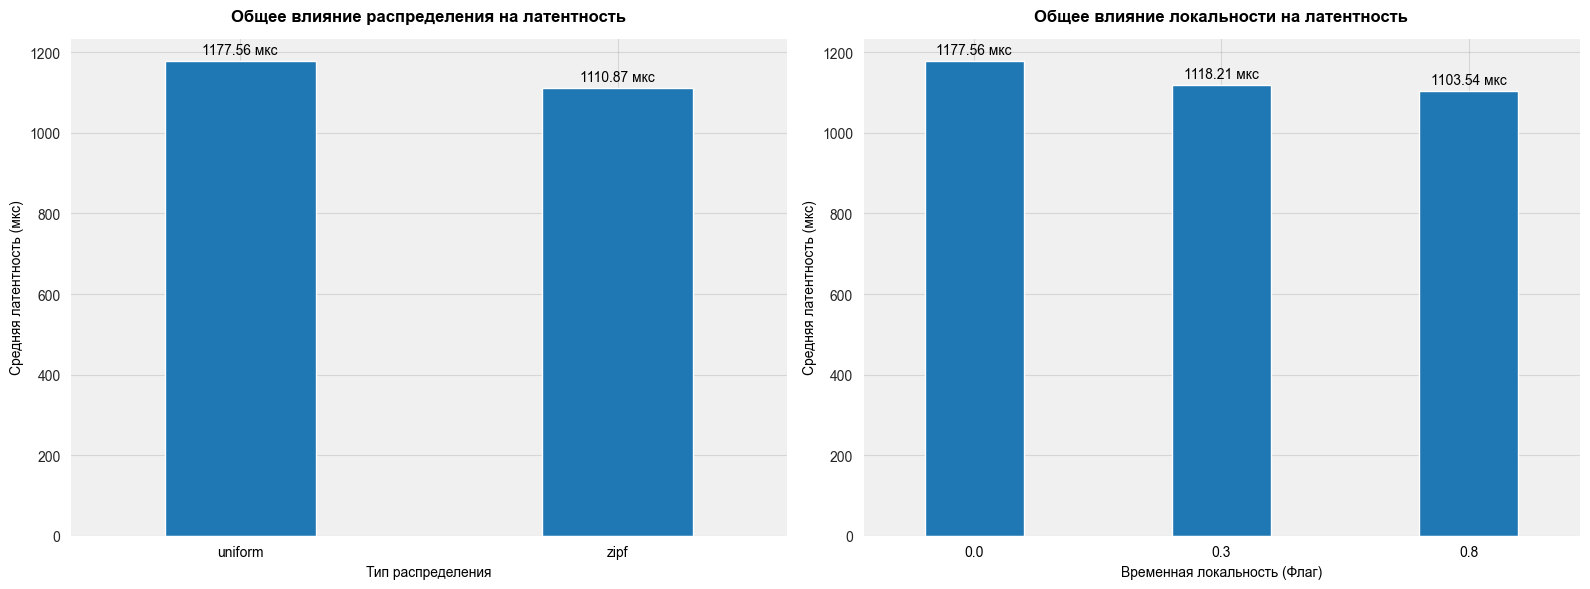

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

zipf_effect = df.groupby('distribution')['avg_latency_us'].mean()

zipf_effect.plot(kind='bar', ax=axes[0], width=0.4)
axes[0].set_title('Общее влияние распределения на латентность', fontweight='bold', pad=12)
axes[0].set_xlabel('Тип распределения')
axes[0].set_ylabel('Средняя латентность (мкс)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(True, alpha=0.3)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f мкс', padding=3)

loc_effect = df.groupby('locality')['avg_latency_us'].mean()

loc_effect.plot(kind='bar', ax=axes[1], width=0.4)
axes[1].set_title('Общее влияние локальности на латентность', fontweight='bold', pad=12)
axes[1].set_xlabel('Временная локальность (Флаг)')
axes[1].set_ylabel('Средняя латентность (мкс)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, alpha=0.3)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f мкс', padding=3)

plt.tight_layout()

Text(0.5, 1.0, 'Корреляционная матрица')

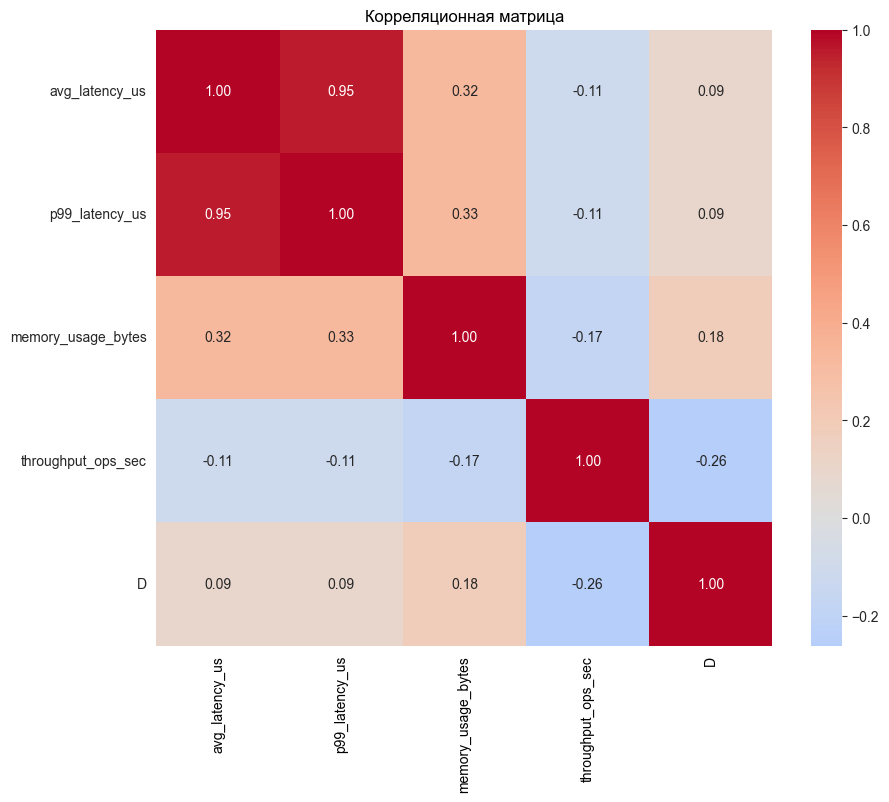

In [59]:
metric_cols = ['avg_latency_us','p99_latency_us','memory_usage_bytes','throughput_ops_sec','D']
corr = df[metric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица')

Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: 0.953


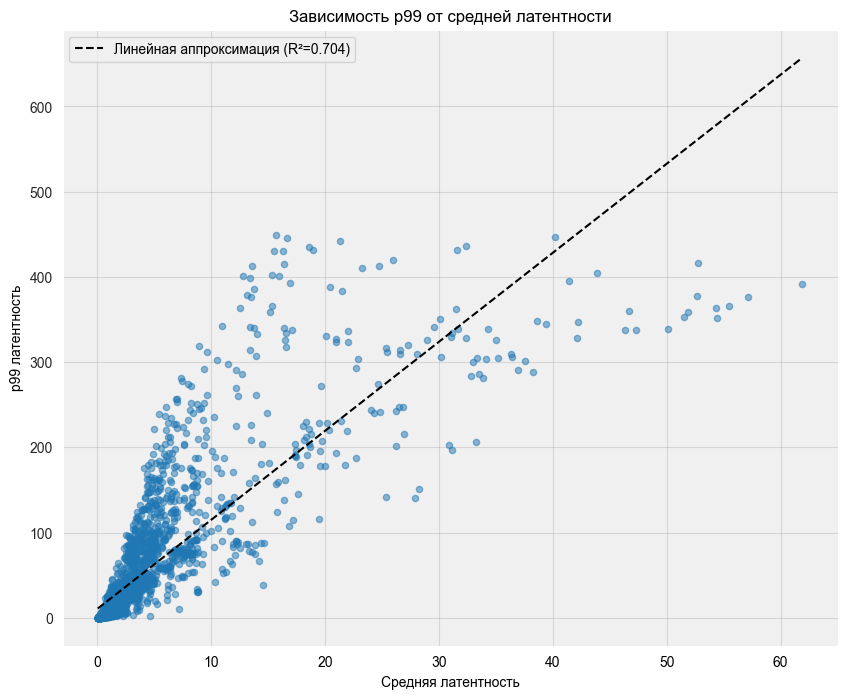

In [37]:
plt.figure(figsize=(10, 8))
sub = df[df['p99_latency_us']<450]
plt.scatter(sub['avg_latency_us'], sub['p99_latency_us'], alpha=0.5, s=20)

coef = np.polyfit(sub['avg_latency_us'], sub['p99_latency_us'], 1)
p = np.poly1d(coef)
x_line = np.linspace(sub['avg_latency_us'].min(), sub['avg_latency_us'].max(), 100)
r2_lin = np.corrcoef(sub['avg_latency_us'], sub['p99_latency_us'])[0,1]**2
plt.plot(x_line, p(x_line), 'k--', label=f'Линейная аппроксимация (R²={r2_lin:.3f})')

plt.xlabel('Средняя латентность')
plt.ylabel('p99 латентность')
plt.title('Зависимость p99 от средней латентности')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: {pearsonr(df['avg_latency_us'], df['p99_latency_us'])[0]:.3f}")

C:\Users\дима\AppData\Local\Temp\ipykernel_24112\396200768.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


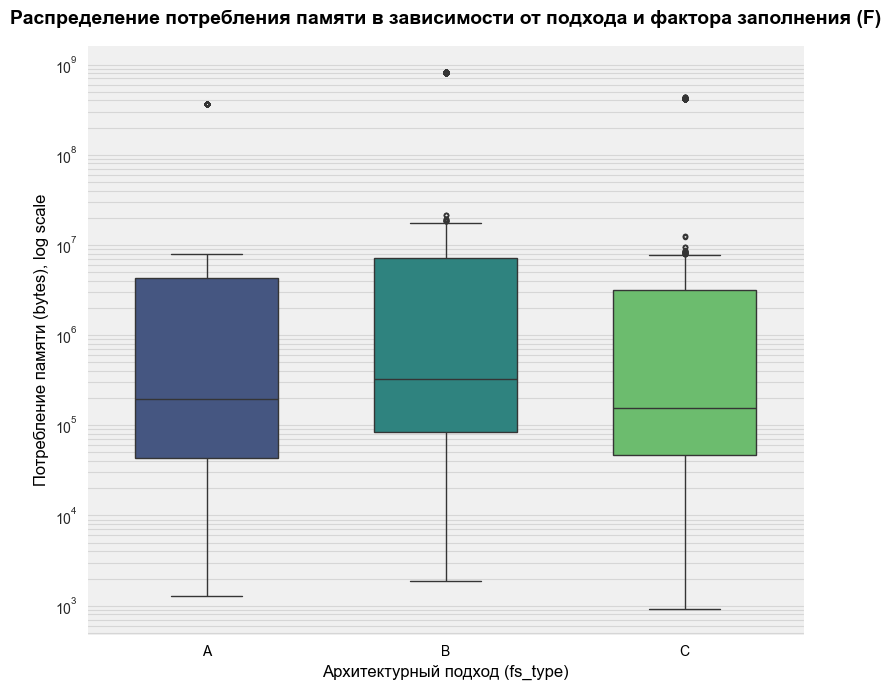

In [54]:

plt.figure(figsize=(8, 7))

sns.boxplot(
    data=df, 
    x='fs_type', 
    y='memory_usage_bytes', 
    palette='viridis', 
    width=0.6,
    fliersize=3,
    legend=False
)

plt.yscale('log')

plt.title('Распределение потребления памяти в зависимости от подхода и фактора заполнения (F)', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Архитектурный подход (fs_type)', fontsize=12)
plt.ylabel('Потребление памяти (bytes), log scale', fontsize=12)
plt.grid(True, which="both", alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: 0.844


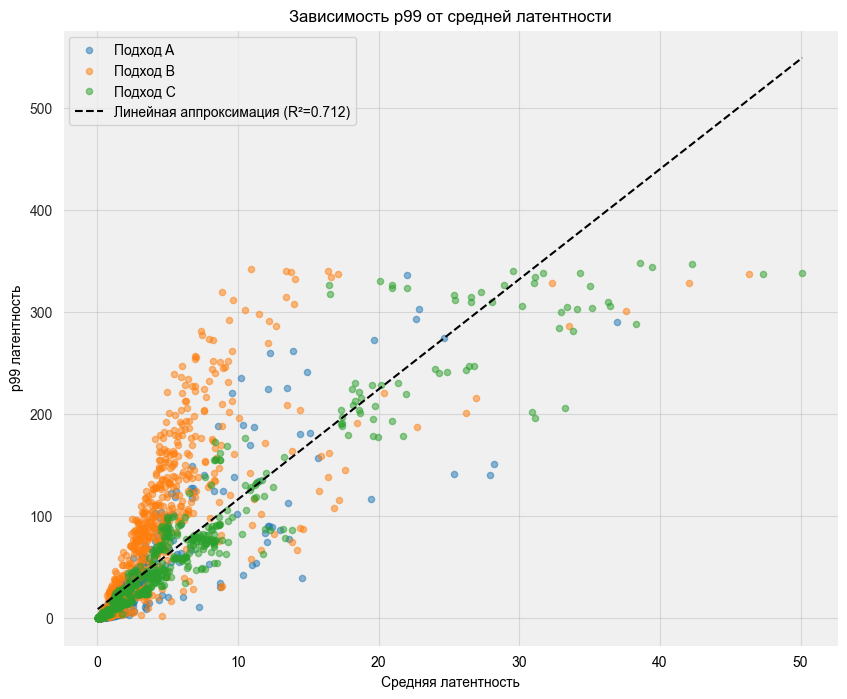

In [49]:
df_s = df[df['p99_latency_us']<350]

plt.figure(figsize=(10, 8))
for approach in ['A','B','C']:
    sub = df_s[df_s['fs_type']==approach]
    plt.scatter(sub['avg_latency_us'], sub['p99_latency_us'], alpha=0.5, s=20, label=f'Подход {approach}')

coef = np.polyfit(df_s['avg_latency_us'], df_s['p99_latency_us'], 1)
p = np.poly1d(coef)
x_line = np.linspace(df_s['avg_latency_us'].min(), df_s['avg_latency_us'].max(), 100)
r2_lin = np.corrcoef(df_s['avg_latency_us'], df_s['p99_latency_us'])[0,1]**2
plt.plot(x_line, p(x_line), 'k--', label=f'Линейная аппроксимация (R²={r2_lin:.3f})')

plt.xlabel('Средняя латентность')
plt.ylabel('p99 латентность')
plt.title('Зависимость p99 от средней латентности')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: {pearsonr(df_s['avg_latency_us'], df_s['p99_latency_us'])[0]:.3f}")

Подход A: коэффициент корреляции Пирсона = 0.873
Подход B: коэффициент корреляции Пирсона = 0.782
Подход C: коэффициент корреляции Пирсона = 0.954


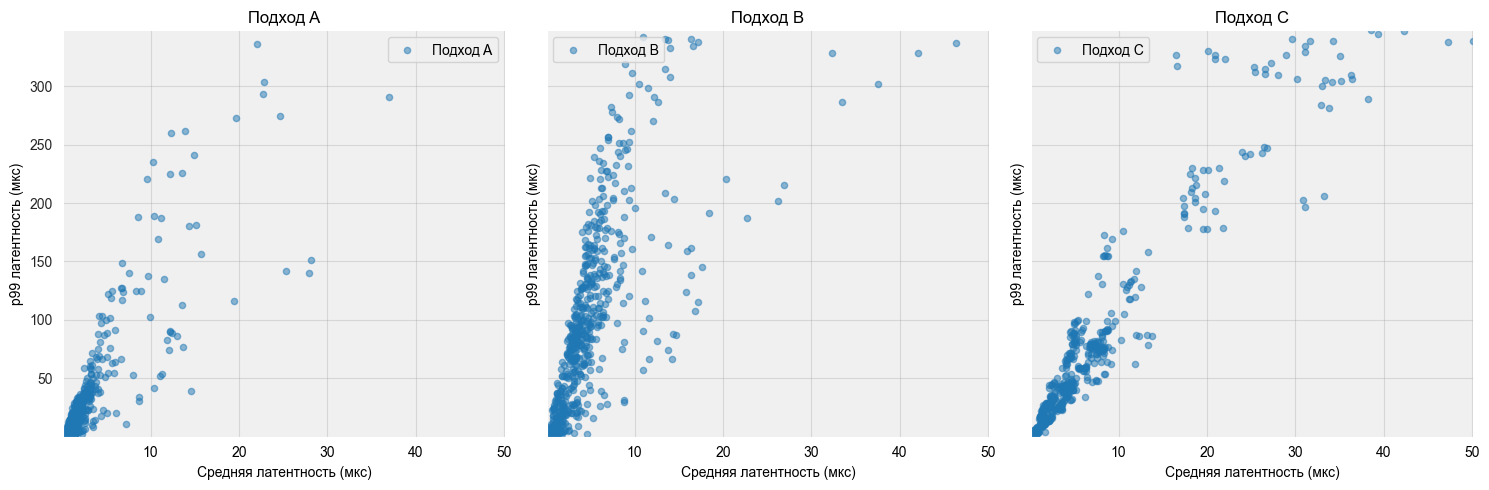

In [58]:
x_min = df_s['avg_latency_us'].min()
x_max = df_s['avg_latency_us'].max()
y_min = df_s['p99_latency_us'].min()
y_max = df_s['p99_latency_us'].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

approaches = ['A', 'B', 'C']

for ax, approach in zip(axes, approaches):
    sub = df_s[df_s['fs_type'] == approach]
    
    ax.scatter(sub['avg_latency_us'], sub['p99_latency_us'],
               alpha=0.5, s=20, label=f'Подход {approach}')
    
    if len(sub) > 1:
        corr, _ = pearsonr(sub['avg_latency_us'], sub['p99_latency_us'])
        print(f"Подход {approach}: коэффициент корреляции Пирсона = {corr:.3f}")
    
    ax.set_xlabel('Средняя латентность (мкс)')
    ax.set_ylabel('p99 латентность (мкс)')
    ax.set_title(f'Подход {approach}')
    ax.legend()
    ax.grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns


def analyze_metric_linearity(df, x_col, y_col):
    x = df[x_col].values.reshape(-1, 1)
    y = df[y_col].values
    res = {}

    pearson_r, _ = stats.pearsonr(x.flatten(), y)
    spearman_r, _ = stats.spearmanr(x.flatten(), y)
    res['pearson_r'] = pearson_r
    res['spearman_r'] = spearman_r
    res['monotonic_gap'] = abs(spearman_r) - abs(pearson_r)

    lin = LinearRegression().fit(x, y)
    res['r2_linear'] = r2_score(y, lin.predict(x))
    res['slope'] = lin.coef_[0]

    poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(x, y)
    res['r2_poly2'] = r2_score(y, poly.predict(x))
    res['nonlinearity_gain'] = res['r2_poly2'] - res['r2_linear']

    iso = IsotonicRegression(out_of_bounds='clip')
    res['r2_isotonic_ceiling'] = r2_score(y, iso.fit_transform(x.flatten(), y))

    resid = y - lin.predict(x)
    bp_corr, bp_p = stats.pearsonr(x.flatten(), resid ** 2)
    res['heteroscedasticity_corr'] = bp_corr
    res['heteroscedasticity_p'] = bp_p

    mask = (df[x_col] > 0) & (df[y_col] > 0)
    if mask.sum() > 10:
        log_x, log_y = np.log(df.loc[mask, x_col]), np.log(df.loc[mask, y_col])
        slope, intercept, r_val, _, _ = linregress(log_x, log_y)
        res['power_law_exponent'] = slope
        res['power_law_r2'] = r_val ** 2

    return res


def plot_relationship(df, x_col, y_col, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    sns.regplot(x=x_col, y=y_col, data=df, ax=ax,
                scatter_kws={'alpha': 0.4, 's': 18},
                line_kws={'color': 'red', 'label': 'Линейная'})
    
    sns.regplot(x=x_col, y=y_col, data=df, ax=ax, scatter=False, lowess=True,
                line_kws={'color': 'green', 'linestyle': '--', 'label': 'LOWESS (фактический тренд)'})
    
    ax.set_title(f'{y_col} vs {x_col}')
    ax.legend()
    return ax


metrics = ['avg_latency_us', 'p99_latency_us', 'memory_usage_bytes', 'throughput_ops_sec']
pairs = [(a, b) for i, a in enumerate(metrics) for b in metrics[i + 1:]]

summary = pd.DataFrame([
    {**analyze_metric_linearity(df, x, y), 'pair': f'{x} vs {y}'}
    for x, y in pairs
]).set_index('pair')

print(summary[['pearson_r', 'spearman_r', 'monotonic_gap',
                'r2_linear', 'r2_poly2', 'nonlinearity_gain',
                'r2_isotonic_ceiling', 'power_law_exponent']].round(3))


                                          pearson_r  spearman_r  \
pair                                                              
avg_latency_us vs p99_latency_us              0.953       0.971   
avg_latency_us vs memory_usage_bytes          0.321       0.499   
avg_latency_us vs throughput_ops_sec         -0.111      -0.998   
p99_latency_us vs memory_usage_bytes          0.327       0.472   
p99_latency_us vs throughput_ops_sec         -0.113      -0.971   
memory_usage_bytes vs throughput_ops_sec     -0.169      -0.485   

                                          monotonic_gap  r2_linear  r2_poly2  \
pair                                                                           
avg_latency_us vs p99_latency_us                  0.018      0.908     0.960   
avg_latency_us vs memory_usage_bytes              0.178      0.103     0.114   
avg_latency_us vs throughput_ops_sec              0.887      0.012     0.015   
p99_latency_us vs memory_usage_bytes              0.144      0.

In [ ]:
import plotly.express as px
import numpy as np

def plot_3d_interactive(df, log_scale=True, color_by='memory_usage_bytes', system_name=''):
    plot_df = df.copy()
    cols = ['avg_latency_us', 'p99_latency_us','throughput_ops_sec']

    if log_scale:
        for col in cols:
            plot_df[col] = np.log1p(plot_df[col])

    fig = px.scatter_3d(
        plot_df, x='avg_latency_us', y='p99_latency_us', z='throughput_ops_sec',
        color=color_by, opacity=0.75, color_continuous_scale='Viridis',
        title=f'3D-связь латентностей и throughput {f"— {system_name}" if system_name else ""}',
        labels={c: f'{c}' if log_scale else c for c in cols},
    )
    fig.update_traces(marker=dict(size=4, line=dict(width=0.5, color='DarkSlateGrey')))
    fig.update_layout(width=900, height=750)
    fig.show()
    return fig


plot_3d_interactive(df, log_scale=True, color_by='memory_usage_bytes')